# OrganAMNIST CNN Filter and Complexity Lab

**Aim:** Explore convolutional filters, layer-wise image structure, model complexity, augmentation, class imbalance, and custom Keras code on OrganAMNIST abdominal CT slices.

**Medical-data caution:** These are resized educational benchmark slices, not complete patient studies or clinical diagnostic evidence. Each section uses short **what / why** explanations.

## 1. Setup and reproducibility

**What:** Import numerical, medical-dataset, deep-learning, plotting, and evaluation tools.
**Why:** Reproducible seeds and explicit dependencies make the experiment auditable.

In [1]:
import os
import random
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import medmnist
from medmnist import INFO
from medmnist.dataset import OrganAMNIST
from IPython.display import display, Markdown
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
np.set_printoptions(precision=3, suppress=True)
print(f"Python: {sys.version.split()[0]}")
print(f"TensorFlow: {tf.__version__}")
print(f"MedMNIST: {medmnist.__version__}")
print(f"NumPy: {np.__version__}")

Python: 3.14.6
TensorFlow: 2.22.0-rc0
MedMNIST: 3.0.2
NumPy: 2.5.1


## 2. OrganAMNIST metadata and official splits

**What:** Load the official MedMNIST train, validation, and test partitions.
**Why:** Preserving the published split keeps final evaluation independent from model development.

In [2]:
DATA_FLAG = "organamnist"
info = INFO[DATA_FLAG]
class_names = [info["label"][str(i)] for i in range(len(info["label"]))]
num_classes = len(class_names)
assert num_classes == 11
print("Dataset:", info["description"])
print("Classes:", class_names)

train_dataset = OrganAMNIST(split="train", download=True)
val_dataset = OrganAMNIST(split="val", download=True)
test_dataset = OrganAMNIST(split="test", download=True)
print("Raw structures:", train_dataset.imgs.shape, train_dataset.labels.shape)

def prepare_medical_split(dataset):
    images = dataset.imgs.astype("float32") / 255.0
    labels = dataset.labels.reshape(-1).astype("int64")
    images = images[..., np.newaxis]
    assert images.shape[1:] == (28, 28, 1)
    assert labels.shape[0] == images.shape[0]
    assert labels.min() >= 0 and labels.max() < num_classes
    assert np.isfinite(images).all() and 0.0 <= images.min() <= images.max() <= 1.0
    return images, labels

train_images, y_train = prepare_medical_split(train_dataset)
val_images, y_val = prepare_medical_split(val_dataset)
test_images, y_test = prepare_medical_split(test_dataset)
split_summary = pd.DataFrame([
    {"split": name, "images": len(images), "image_structure": images.shape[1:], "labels": labels.shape}
    for name, images, labels in [("train", train_images, y_train), ("validation", val_images, y_val), ("test", test_images, y_test)]
])
display(split_summary)
print(f"Prepared image structure: {train_images.shape[1:]}; labels: {y_train.shape}; classes: {num_classes}")

Dataset: The OrganAMNIST is based on 3D computed tomography (CT) images from Liver Tumor Segmentation Benchmark (LiTS). It is renamed from OrganMNIST_Axial (in MedMNIST v1) for simplicity. We use bounding-box annotations of 11 body organs from another study to obtain the organ labels. Hounsfield-Unit (HU) of the 3D images are transformed into gray-scale with an abdominal window. We crop 2D images from the center slices of the 3D bounding boxes in axial views (planes). The images are resized into 1×28×28 to perform multi-class classification of 11 body organs. 115 and 16 CT scans from the source training set are used as training and validation set, respectively. The 70 CT scans from the source test set are treated as the test set.
Classes: ['bladder', 'femur-left', 'femur-right', 'heart', 'kidney-left', 'kidney-right', 'liver', 'lung-left', 'lung-right', 'pancreas', 'spleen']


Raw structures: (34561, 28, 28) (34561, 1)


,split,images,image_structure,labels
0,train,34561,"(28, 28, 1)","(34561,)"
1,validation,6491,"(28, 28, 1)","(6491,)"
2,test,17778,"(28, 28, 1)","(17778,)"


Prepared image structure: (28, 28, 1); labels: (34561,); classes: 11


,class_id,organ,training_count
0,0,bladder,1956
1,1,femur-left,1390
2,2,femur-right,1357
3,3,heart,1474
4,4,kidney-left,3963
5,5,kidney-right,3817
6,6,liver,6164
7,7,lung-left,3919
8,8,lung-right,3929
9,9,pancreas,3031


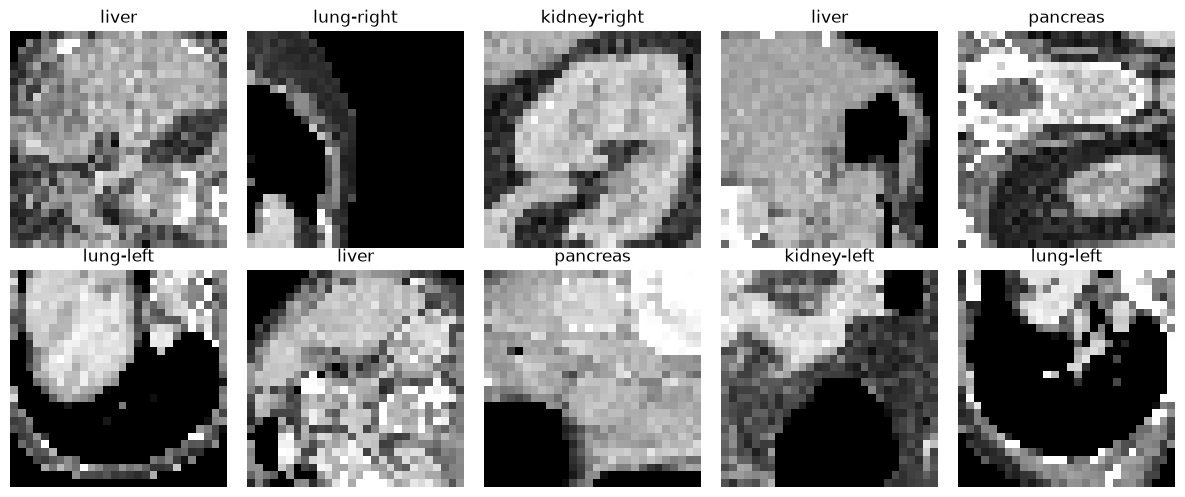

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, image, label in zip(axes.ravel(), train_images[:10], y_train[:10]):
    ax.imshow(image[..., 0], cmap="gray")
    ax.set_title(class_names[int(label)])
    ax.axis("off")
plt.tight_layout()
class_counts = np.bincount(y_train, minlength=num_classes)
class_distribution = pd.DataFrame({"class_id": np.arange(num_classes), "organ": class_names, "training_count": class_counts})
display(class_distribution)
assert class_counts.sum() == len(y_train)

## 3. Training-only augmentation and class imbalance

**What:** Create small geometric changes for training and balanced loss weights from training labels only.
**Why:** Augmentation improves variation while class weights reduce the influence of dominant classes without modifying validation or test images.

Validation and test images are not augmented.


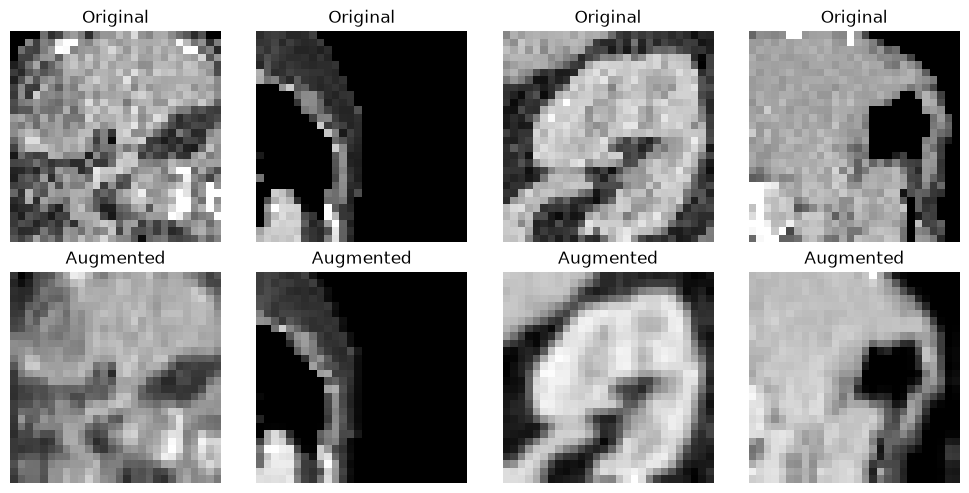

In [4]:
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05, seed=SEED),
    tf.keras.layers.RandomTranslation(0.05, 0.05, seed=SEED),
], name="training_augmentation")
preview = tf.convert_to_tensor(train_images[:4])
augmented_preview = augmentation(preview, training=True).numpy()
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for index in range(4):
    axes[0, index].imshow(preview[index, ..., 0], cmap="gray"); axes[0, index].set_title("Original"); axes[0, index].axis("off")
    axes[1, index].imshow(augmented_preview[index, ..., 0], cmap="gray"); axes[1, index].set_title("Augmented"); axes[1, index].axis("off")
plt.tight_layout()
assert augmented_preview.shape == preview.shape
print("Validation and test images are not augmented.")

In [5]:
class_ids = np.arange(num_classes)
weights = compute_class_weight(class_weight="balanced", classes=class_ids, y=y_train)
class_weights = dict(zip(class_ids.tolist(), weights.tolist()))
weight_table = class_distribution.copy()
weight_table["class_weight"] = weights
display(weight_table)
assert np.isfinite(weights).all() and (weights > 0).all()

,class_id,organ,training_count,class_weight
0,0,bladder,1956,1.606293
1,1,femur-left,1390,2.260366
2,2,femur-right,1357,2.315335
3,3,heart,1474,2.131553
4,4,kidney-left,3963,0.792811
5,5,kidney-right,3817,0.823136
6,6,liver,6164,0.509719
7,7,lung-left,3919,0.801712
8,8,lung-right,3929,0.799671
9,9,pancreas,3031,1.036592


## 4. Fixed filters and a custom Keras layer

**What:** Compare hand-designed kernels with a user-defined non-trainable TensorFlow layer.
**Why:** Fixed filters explain local image operations; custom layers show how Keras can be extended.

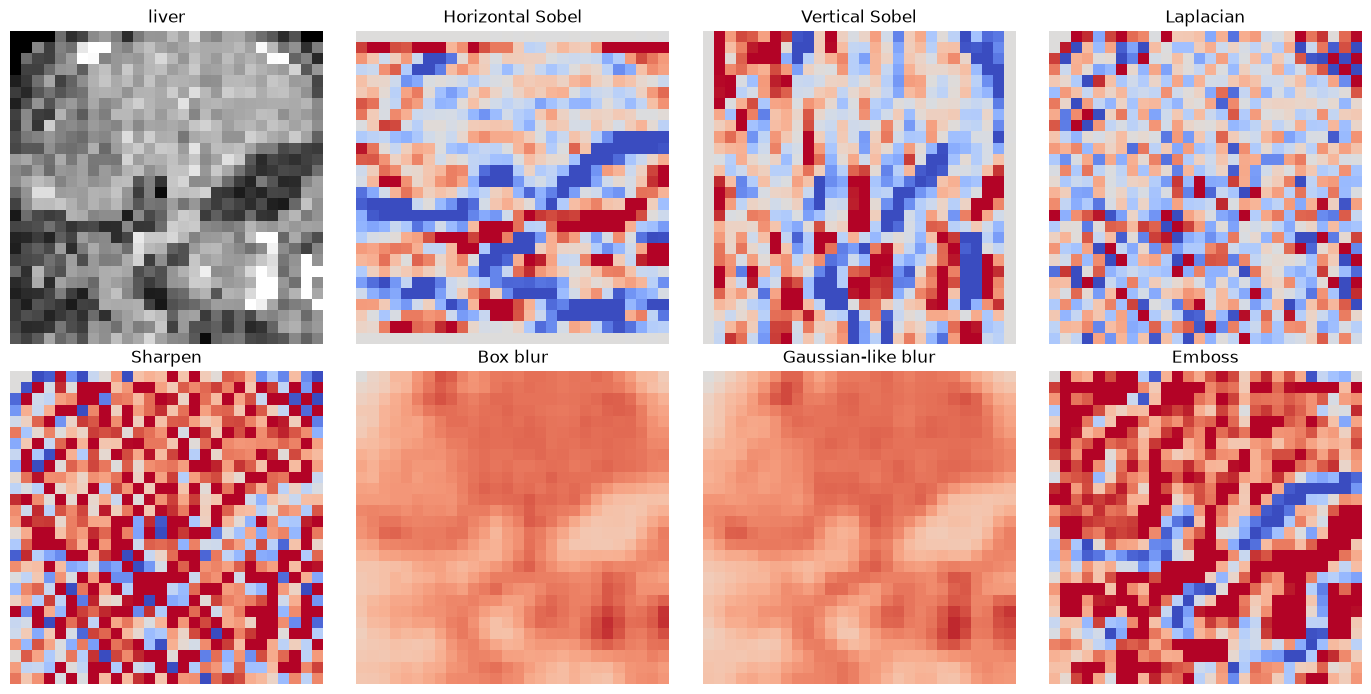

In [6]:
def apply_kernel(image, kernel):
    image = np.asarray(image, dtype=np.float32)
    kernel = np.asarray(kernel, dtype=np.float32)
    assert image.ndim == 2 and kernel.shape == (3, 3)
    padded = np.pad(image, 1, mode="reflect")
    response = np.empty_like(image)
    for row in range(image.shape[0]):
        for col in range(image.shape[1]):
            response[row, col] = np.sum(padded[row:row + 3, col:col + 3] * kernel)
    return response

FILTERS = {
    "Horizontal Sobel": np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32),
    "Vertical Sobel": np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32),
    "Laplacian": np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=np.float32),
    "Sharpen": np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float32),
    "Box blur": np.ones((3, 3), dtype=np.float32) / 9,
    "Gaussian-like blur": np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]], dtype=np.float32) / 16,
    "Emboss": np.array([[-2, -1, 0], [-1, 1, 1], [0, 1, 2]], dtype=np.float32),
}
source_image = train_images[0, ..., 0]
filter_responses = {name: apply_kernel(source_image, kernel) for name, kernel in FILTERS.items()}
assert all(response.shape == source_image.shape for response in filter_responses.values())
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.ravel(); axes[0].imshow(source_image, cmap="gray", vmin=0, vmax=1); axes[0].set_title(class_names[int(y_train[0])])
for ax, (name, response) in zip(axes[1:], filter_responses.items()):
    ax.imshow(response, cmap="coolwarm", vmin=-1, vmax=1); ax.set_title(name)
for ax in axes: ax.axis("off")
plt.tight_layout()

In [7]:
class FixedKernelLayer(tf.keras.layers.Layer):
    def __init__(self, kernel, **kwargs):
        super().__init__(**kwargs)
        kernel = np.asarray(kernel, dtype="float32")
        assert kernel.shape == (3, 3)
        self.kernel_values = kernel

    def build(self, input_shape):
        channels = int(input_shape[-1])
        kernel = np.repeat(self.kernel_values[:, :, None, None], channels, axis=2)
        self.kernel = tf.constant(kernel, dtype=tf.float32)

    def call(self, inputs):
        return tf.nn.depthwise_conv2d(inputs, self.kernel, strides=[1, 1, 1, 1], padding="SAME")

custom_layer = FixedKernelLayer(FILTERS["Laplacian"], name="fixed_laplacian")
custom_output = custom_layer(train_images[:1])
print("Custom layer structure:", train_images[:1].shape, "->", custom_output.shape)
assert tuple(custom_output.shape) == (1, 28, 28, 1)
assert len(custom_layer.trainable_weights) == 0

Custom layer structure: (1, 28, 28, 1) -> (1, 28, 28, 1)


## 5. Built-in Keras convolution and pooling

**What:** Run learned `Conv2D` filters and max pooling on one medical image.
**Why:** Built-in layers learn kernels from examples and reduce spatial resolution efficiently.

In [8]:
builtin_conv = tf.keras.layers.Conv2D(filters=4, kernel_size=3, padding="same", activation="relu", kernel_initializer=tf.keras.initializers.GlorotUniform(seed=SEED))
builtin_pool = tf.keras.layers.MaxPooling2D(pool_size=2)
builtin_features = builtin_conv(train_images[:1])
builtin_pooled = builtin_pool(builtin_features)
print("Built-in structures:", train_images[:1].shape, "->", builtin_features.shape, "->", builtin_pooled.shape)
assert tuple(builtin_features.shape) == (1, 28, 28, 4)
assert tuple(builtin_pooled.shape) == (1, 14, 14, 4)

Built-in structures: (1, 28, 28, 1) -> (1, 28, 28, 4) -> (1, 14, 14, 4)


## 6. CNN shape trace and complexity

**What:** Build an 11-class CNN and record every layer output, parameter count, activation count, and approximate MACs.
**Why:** Channels increase representational capacity while pooling reduces later spatial computation.

In [9]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1), name="input"),
    augmentation,
    tf.keras.layers.Conv2D(8, 3, padding="same", activation="relu", name="conv1"),
    tf.keras.layers.MaxPooling2D(2, name="pool1"),
    tf.keras.layers.Conv2D(16, 3, padding="same", activation="relu", name="conv2"),
    tf.keras.layers.MaxPooling2D(2, name="pool2"),
    tf.keras.layers.Dropout(0.25, name="dropout"),
    tf.keras.layers.Flatten(name="flatten"),
    tf.keras.layers.Dense(64, activation="relu", name="dense"),
    tf.keras.layers.Dropout(0.25, name="dense_dropout"),
    tf.keras.layers.Dense(num_classes, activation="softmax", name="classifier"),
])
model.compile(optimizer=tf.keras.optimizers.Adam(), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()
print(f"Key structure: (28, 28, 1) -> (28, 28, 8) -> (14, 14, 8) -> (14, 14, 16) -> (7, 7, 16) -> ({num_classes},)")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ training_augmentation           │ (None, 28, 28, 1)      │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 28, 28, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_dropout (Dropout)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 11)             │           715 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,203 (203.92 KB)

 Trainable params: 52,203 (203.92 KB)

 Non-trainable params: 0 (0.00 B)

Key structure: (28, 28, 1) -> (28, 28, 8) -> (14, 14, 8) -> (14, 14, 16) -> (7, 7, 16) -> (11,)


In [10]:
def trace_model_shapes(model, input_shape):
    tensor = tf.zeros((1, *input_shape), dtype=tf.float32)
    rows = [{"layer": "input", "output_shape": tuple(tensor.shape[1:]), "activations": int(np.prod(tensor.shape[1:]))}]
    for layer in model.layers:
        tensor = layer(tensor, training=False)
        rows.append({"layer": layer.name, "output_shape": tuple(tensor.shape[1:]), "activations": int(np.prod(tensor.shape[1:]))})
    return pd.DataFrame(rows)

shape_table = trace_model_shapes(model, (28, 28, 1))
display(shape_table)
assert tuple(shape_table.iloc[0].output_shape) == (28, 28, 1)
assert tuple(shape_table.loc[shape_table.layer == "pool1", "output_shape"].iloc[0]) == (14, 14, 8)
assert tuple(shape_table.loc[shape_table.layer == "pool2", "output_shape"].iloc[0]) == (7, 7, 16)
assert tuple(shape_table.iloc[-1].output_shape) == (num_classes,)

,layer,output_shape,activations
0,input,"(28, 28, 1)",784
1,training_augmentation,"(28, 28, 1)",784
2,conv1,"(28, 28, 8)",6272
3,pool1,"(14, 14, 8)",1568
4,conv2,"(14, 14, 16)",3136
5,pool2,"(7, 7, 16)",784
6,dropout,"(7, 7, 16)",784
7,flatten,"(784,)",784
8,dense,"(64,)",64
9,dense_dropout,"(64,)",64


In [11]:
def complexity_rows(model, input_shape):
    tensor = tf.zeros((1, *input_shape), dtype=tf.float32)
    rows = []
    for layer in model.layers:
        input_tensor = tensor
        tensor = layer(tensor, training=False)
        output_shape = tuple(int(dim) for dim in tensor.shape[1:])
        params = int(layer.count_params())
        macs = 0
        if isinstance(layer, tf.keras.layers.Conv2D):
            kh, kw = layer.kernel_size
            macs = int(np.prod(output_shape) * kh * kw * int(input_tensor.shape[-1]))
        elif isinstance(layer, tf.keras.layers.Dense):
            macs = int(input_tensor.shape[-1] * layer.units)
        rows.append({"layer": layer.name, "output_shape": output_shape, "parameters": params, "activations": int(np.prod(output_shape)), "approx_MACs": macs})
    return pd.DataFrame(rows)

complexity_table = complexity_rows(model, (28, 28, 1))
display(complexity_table)
print("Total trainable parameters:", complexity_table.parameters.sum())
print("Keras model parameters:", model.count_params())
print("Total approximate MACs:", complexity_table.approx_MACs.sum())
assert complexity_table.parameters.sum() == model.count_params()

,layer,output_shape,parameters,activations,approx_MACs
0,training_augmentation,"(28, 28, 1)",0,784,0
1,conv1,"(28, 28, 8)",80,6272,56448
2,pool1,"(14, 14, 8)",0,1568,0
3,conv2,"(14, 14, 16)",1168,3136,225792
4,pool2,"(7, 7, 16)",0,784,0
5,dropout,"(7, 7, 16)",0,784,0
6,flatten,"(784,)",0,784,0
7,dense,"(64,)",50240,64,50176
8,dense_dropout,"(64,)",0,64,0
9,classifier,"(11,)",715,11,704


Total trainable parameters: 52203
Keras model parameters: 52203
Total approximate MACs: 333120


## 7. Training with class weights

**What:** Train with augmentation active only in training mode and class weights computed from training labels.
**Why:** These controls address geometric variation and class imbalance separately.

Epoch 1/20


271/271 - 6s - 21ms/step - accuracy: 0.5203 - loss: 1.3688 - val_accuracy: 0.9068 - val_loss: 0.3973


Epoch 2/20


271/271 - 4s - 15ms/step - accuracy: 0.7258 - loss: 0.7847 - val_accuracy: 0.9364 - val_loss: 0.2485


Epoch 3/20


...

271/271 - 4s - 16ms/step - accuracy: 0.8662 - loss: 0.3604 - val_accuracy: 0.9452 - val_loss: 0.1829


Epoch 11/20


271/271 - 4s - 16ms/step - accuracy: 0.8776 - loss: 0.3278 - val_accuracy: 0.9410 - val_loss: 0.1865


Epoch 12/20


271/271 - 4s - 16ms/step - accuracy: 0.8826 - loss: 0.3104 - val_accuracy: 0.9535 - val_loss: 0.1484


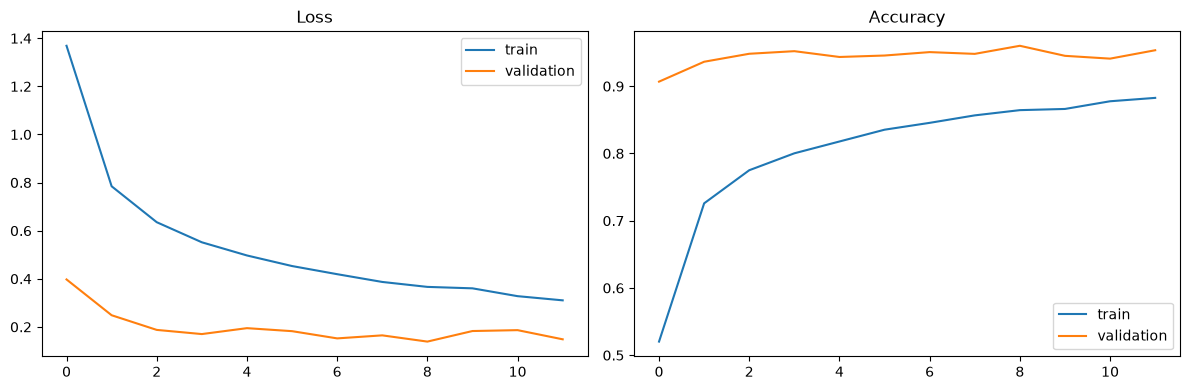

In [12]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
history = model.fit(train_images, y_train, validation_data=(val_images, y_val), epochs=20, batch_size=128, class_weight=class_weights, callbacks=[early_stopping], verbose=2)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="train"); axes[0].plot(history.history["val_loss"], label="validation"); axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(history.history["accuracy"], label="train"); axes[1].plot(history.history["val_accuracy"], label="validation"); axes[1].set_title("Accuracy"); axes[1].legend()
plt.tight_layout()

## 8. Final OrganAMNIST evaluation

**What:** Evaluate once on the untouched official test split using organ-aware metrics.
**Why:** Macro scores and the confusion matrix reveal minority-class failures that accuracy can hide.

,loss,accuracy,macro_f1,weighted_f1
0,0.514874,0.829452,0.831765,0.826235


,precision,recall,f1-score,support
bladder,0.930,0.714,0.808,1036.000
femur-left,0.974,0.815,0.888,784.000
femur-right,0.924,0.831,0.875,793.000
heart,0.834,0.959,0.892,785.000
kidney-left,0.713,0.572,0.634,2064.000
kidney-right,0.734,0.709,0.721,1965.000
liver,0.854,0.975,0.911,3285.000
lung-left,0.942,0.994,0.967,1747.000
lung-right,0.976,0.981,0.979,1813.000
pancreas,0.754,0.761,0.757,1622.000


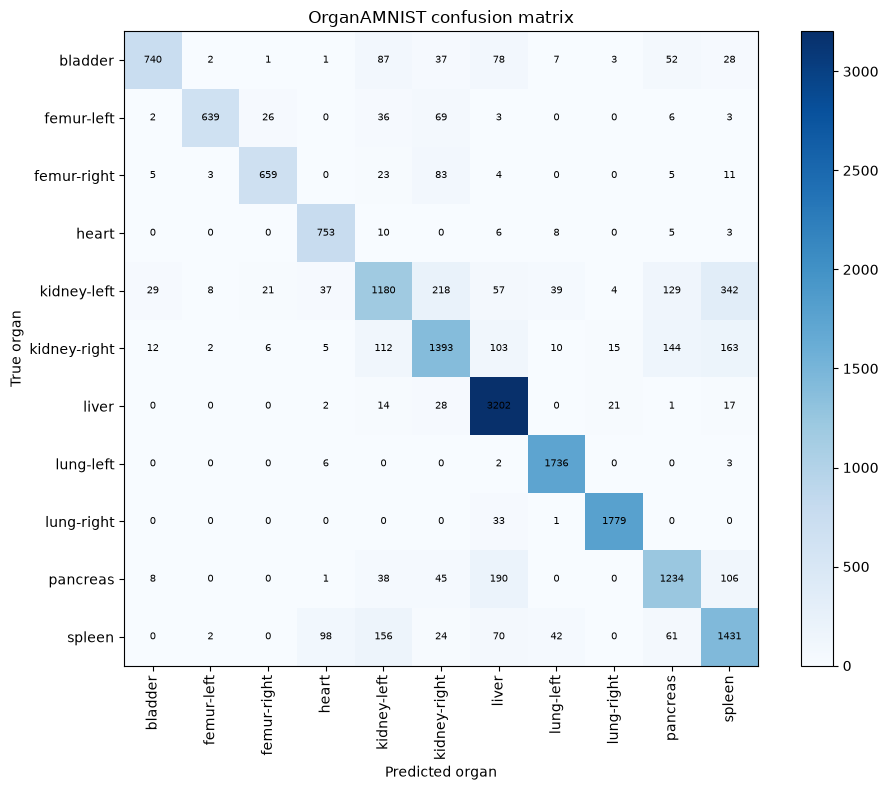

In [13]:
test_loss, test_accuracy = model.evaluate(test_images, y_test, verbose=0)
probabilities = model.predict(test_images, verbose=0)
y_pred = probabilities.argmax(axis=1)
assert len(y_pred) == len(y_test)
report = classification_report(y_test, y_pred, labels=np.arange(num_classes), target_names=class_names, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T
test_metrics = {"loss": float(test_loss), "accuracy": float(test_accuracy), "macro_f1": float(report["macro avg"]["f1-score"]), "weighted_f1": float(report["weighted avg"]["f1-score"])}
display(pd.DataFrame([test_metrics])); display(report_df.round(3))
cm = confusion_matrix(y_test, y_pred, labels=np.arange(num_classes))
assert cm.shape == (num_classes, num_classes)
fig, ax = plt.subplots(figsize=(10, 8)); image = ax.imshow(cm, cmap="Blues"); fig.colorbar(image, ax=ax)
ax.set(xlabel="Predicted organ", ylabel="True organ", title="OrganAMNIST confusion matrix")
ax.set_xticks(range(num_classes), class_names, rotation=90); ax.set_yticks(range(num_classes), class_names)
for row in range(num_classes):
    for col in range(num_classes):
        ax.text(col, row, cm[row, col], ha="center", va="center", fontsize=7)
plt.tight_layout()

## 9. Learned filters and feature maps

**What:** Visualize learned first-layer kernels and feature maps for one CT slice.
**Why:** Learned filters adapt to training examples rather than following a fixed hand-designed rule.

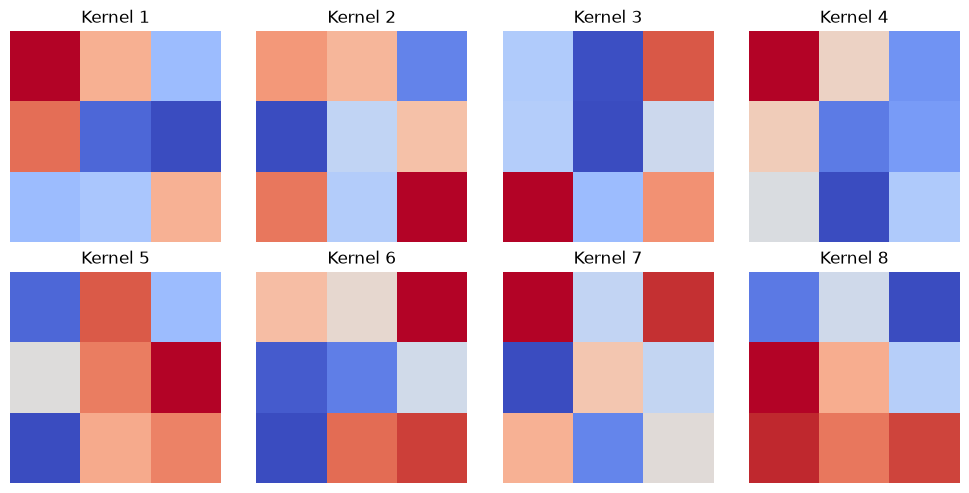

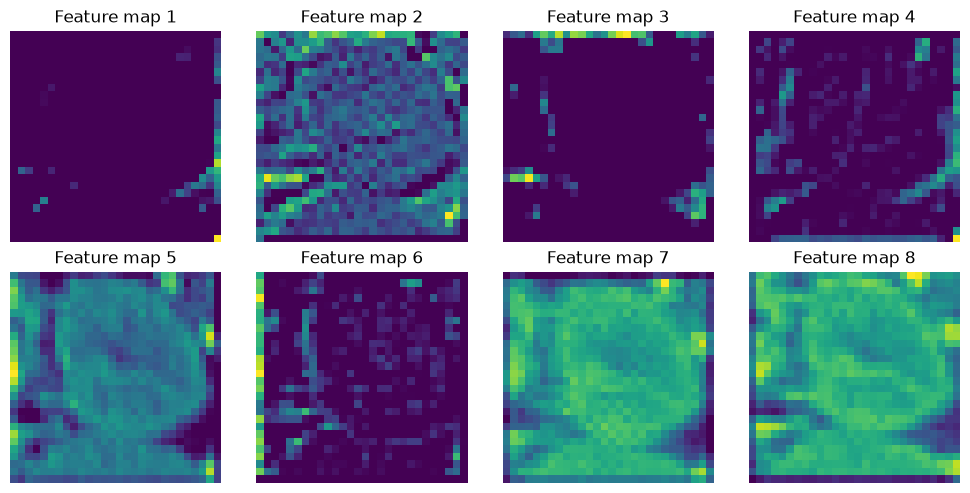

In [14]:
conv1 = model.get_layer("conv1")
learned_kernels = conv1.get_weights()[0]
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for index, ax in enumerate(axes.ravel()):
    ax.imshow(learned_kernels[..., 0, index], cmap="coolwarm"); ax.set_title(f"Kernel {index + 1}"); ax.axis("off")
plt.tight_layout()
feature_input = tf.keras.Input(shape=(28, 28, 1), name="feature_input")
feature_model = tf.keras.Model(feature_input, conv1(feature_input))
feature_maps = feature_model.predict(test_images[:1], verbose=0)[0]
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for index, ax in enumerate(axes.ravel()):
    ax.imshow(feature_maps[..., index], cmap="viridis"); ax.set_title(f"Feature map {index + 1}"); ax.axis("off")
plt.tight_layout()

## 10. Beginner-error audit and references

| Common mistake | Notebook fix |
|---|---|
| Data leakage | Keep official test data isolated until final evaluation. |
| Test-set tuning | Use validation loss for model decisions. |
| Ignoring overfitting | Plot validation curves and restore best weights. |
| Shape/channel errors | Assert rank and print every layer structure. |
| Uncontrolled randomness | Seed Python, NumPy, and TensorFlow. |
| Class imbalance | Inspect counts, compute training-only weights, and report macro metrics. |
| Accuracy-only evaluation | Report per-class metrics and an organ-labeled confusion matrix. |
| Misread filter output | Clip only for visualization; preserve model inputs. |
| Medical overinterpretation | State that resized slices are educational, not clinical validation. |

**References:** [MedMNIST](https://medmnist.com/), [MedMNIST GitHub](https://github.com/MedMNIST/MedMNIST), [scikit-learn common pitfalls](https://scikit-learn.org/stable/common_pitfalls.html), [Google overfitting guidance](https://developers.google.com/machine-learning/crash-course/overfitting), [Keras Conv2D](https://keras.io/api/layers/convolution_layers/convolution2d/), and [Keras EarlyStopping](https://keras.io/api/callbacks/early_stopping/).